In [1]:
%pip install git+https://github.com/kitzeslab/bioacoustics-model-zoo
%pip install tensorflow tensorflow-hub
%pip install iterative-stratification
%pip install umap-learn seaborn

Defaulting to user installation because normal site-packages is not writeable
  Cloning https://github.com/kitzeslab/bioacoustics-model-zoo to /private/var/folders/kb/88tc0y855kl0ynfnf_vk274c0000gn/T/pip-req-build-k6_4oltq
  Running command git clone -q https://github.com/kitzeslab/bioacoustics-model-zoo /private/var/folders/kb/88tc0y855kl0ynfnf_vk274c0000gn/T/pip-req-build-k6_4oltq
  Resolved https://github.com/kitzeslab/bioacoustics-model-zoo to commit b3f2761f33116b70df353384d286a06b2a21fe70
  distutils: /private/var/folders/kb/88tc0y855kl0ynfnf_vk274c0000gn/T/pip-build-env-v4m6ln71/normal/lib/python3.9/site-packages
  sysconfig: /Library/Python/3.9/site-packages
  distutils: /private/var/folders/kb/88tc0y855kl0ynfnf_vk274c0000gn/T/pip-build-env-v4m6ln71/normal/lib/python3.9/site-packages
  sysconfig: /Library/Python/3.9/site-packages
  user = False
  home = None
  root = None
  prefix = '/private/var/folders/kb/88tc0y855kl0ynfnf_vk274c0000gn/T/pip-build-env-v4m6ln71/normal'
  distu

In [2]:
pip list

Package                      Version
---------------------------- -----------
absl-py                      2.3.1
aiohappyeyeballs             2.6.1
aiohttp                      3.13.3
aiosignal                    1.4.0
altgraph                     0.17.2
annotated-types              0.7.0
anyio                        4.12.1
appdirs                      1.4.4
appnope                      0.1.4
argon2-cffi                  25.1.0
argon2-cffi-bindings         25.1.0
arrow                        1.4.0
aru-metadata-parser          0.1.0
asttokens                    3.0.1
astunparse                   1.6.3
async-lru                    2.0.5
async-timeout                5.0.1
attrs                        25.4.0
audioread                    3.1.0
babel                        2.18.0
beautifulsoup4               4.14.3
bioacoustics-model-zoo       0.12.3
birdsong-recognition-dataset 0.3.2.post1
bleach                       6.2.0
certifi                      2026.1.4
cffi                         

In [ ]:
import torch
import random
import numpy as np
torch.manual_seed(0)
random.seed(0)
np.random.seed(0)

In [4]:
import pandas as pd
from pathlib import Path
from glob import glob

# Set path to FFL-Annotations
dataset_path = Path("./FFL-Annotations/")
annotation_files = sorted(glob(f"{dataset_path}/Data/*.txt"))

print("Checking counts with deduplication enabled:")
raw_counts = {}

for ann_file in annotation_files:
    # Use usecols to ensure drop_duplicates compares the right data
    # and to save memory, similar to Snippet 1
    try:
        # We read the file to check headers first
        header = pd.read_csv(ann_file, sep='\t', nrows=0).columns
        call_col = 'TYPE' if 'TYPE' in header else 'CALL'
        
        # Now read only the relevant columns
        cols_to_load = ['SPP', call_col, 'Begin Time (s)', 'End Time (s)', 'Low Freq (Hz)', 'High Freq (Hz)']
        df = pd.read_csv(ann_file, sep='\t', usecols=cols_to_load)
        
        # removes identical rows in the same file (spectrogram 1 vs spectrogram 2)
        rows_before = len(df)
        df = df.drop_duplicates()
        rows_after = len(df)
        
        if rows_before > rows_after:
            print(f"  Removed {rows_before - rows_after} duplicates from {Path(ann_file).name}")


        df['SPECIES_CALL'] = df['SPP'] + '_' + df[call_col]
        
        for label, count in df['SPECIES_CALL'].value_counts().items():
            if label not in raw_counts:
                raw_counts[label] = 0
            raw_counts[label] += count
            
    except Exception as e:
        print(f"Error processing {ann_file}: {e}")

# Show results
sorted_counts = sorted(raw_counts.items(), key=lambda x: x[1], reverse=True)
# print("\nTop 10 counts across all files (Deduplicated):")
# for label, count in sorted_counts[:10]:
#     print(f"  {label}: {count}")
print("\nTop counts across all files:")
for label, count in sorted_counts:
    print(f"  {label}: {count}")


Checking counts with deduplication enabled:
  Removed 33 duplicates from TRIAL4_HAWK_14JUN2024.txt
  Removed 71 duplicates from TRIAL5_HAWK_14JUN2024.txt
  Removed 81 duplicates from TRIAL7_HAWK_15JUN2024.txt

Top counts across all files:
  HARU_C1: 479
  THAR_B2: 197
  THAR_B1: 188
  THAR_P1: 56
  MYME_C1: 55
  MYSP_C1: 51
  THAR_P2: 49
  MYLO_C2: 48
  MYLO_C4: 43
  HARU_C2: 36
  MYAX_C3: 34
  MYMY_C1: 31
  MYAX_C2: 28
  MYAX_C1: 22
  MYLO_C3: 20
  MYLO_C1: 19
  THAR_P3: 16
  MYLO_C6: 14
  MYLO_C5: 12
  MYME_C2: 11
  MYAX_S1: 8
  TOAS_S1: 8
  MYAX_C4: 7
  MYAX_C5: 6
  HARU_S1: 5
  HARU_C4: 4
  HARU_C3: 4
  MYSP_C3: 3
  THAR_B3: 3
  UNK_C1: 2
  THAR_S1: 1
  HARU_B2: 1
  MYLO_S1: 1
  EPHA_S1: 1
  MYSP_C2: 1
  CR_C1: 1
  MYME|C1_C5: 1
  MYSP`_C1: 1


In [5]:
from opensoundscape.annotations import BoxedAnnotations
from pathlib import Path
from glob import glob
import pandas as pd

# Set paths
dataset_path = Path("./FFL-Annotations/")
annotation_files = sorted(glob(f"{dataset_path}/Data/*.txt"))

# Build corresponding audio file paths
audio_files = []
valid_raven_files = []

for raven_path_str in annotation_files:
    raven_path = Path(raven_path_str)
    audio_filename = f"{raven_path.stem}_VILLAANA_MADREDEDIOS.wav"
    audio_path = dataset_path / "Audio" / audio_filename
    
    if audio_path.exists():
        valid_raven_files.append(raven_path)
        audio_files.append(audio_path)
    else:
        print(f"WARNING: Audio file {audio_path} not found, skipping {raven_path.name}")

print(f"Found {len(valid_raven_files)} Raven files with matching audio")

# Load annotations using from_raven_files
boxed_annotations = BoxedAnnotations.from_raven_files(
    raven_files=valid_raven_files,
    audio_files=audio_files,
    annotation_column=None,
    keep_extra_columns=True,
    warn_no_annotations=False
)

print(f"Loaded {len(boxed_annotations.df)} annotations")
# print(boxed_annotations.df[['CALL','TYPE']])
# Combine TYPE and CALL columns (both could exist, use whichever has the value)
if 'TYPE' in boxed_annotations.df.columns and 'CALL' in boxed_annotations.df.columns:
    boxed_annotations.df['call_type'] = boxed_annotations.df['TYPE'].fillna(boxed_annotations.df['CALL'])
elif 'TYPE' in boxed_annotations.df.columns:
    boxed_annotations.df['call_type'] = boxed_annotations.df['TYPE']
else:
    boxed_annotations.df['call_type'] = boxed_annotations.df['CALL']



# Drop rows with missing data

missing_data_rows = boxed_annotations.df[boxed_annotations.df[['SPP', 'call_type']].isna().any(axis=1)]
print("Missing data rows: ")
display(missing_data_rows[['audio_file', 'start_time', 'end_time', 'SPP', 'call_type']])

boxed_annotations.df = boxed_annotations.df.dropna(subset=['SPP', 'call_type'])
print(len(boxed_annotations.df))
# Create annotation
boxed_annotations.df['annotation'] = boxed_annotations.df['SPP'] + '_' + boxed_annotations.df['call_type']

# Remove duplicates
boxed_annotations.df = boxed_annotations.df.drop_duplicates(
    subset=['audio_file', 'start_time', 'end_time', 'annotation']
).reset_index(drop=True)

print(f"\nFinal: {len(boxed_annotations.df)} unique annotations")
print(f"\nFirst few rows:")
print(boxed_annotations.df[['audio_file', 'start_time', 'end_time', 'SPP', 'call_type', 'annotation']].head())
print(f"\nLabel distribution:")
print(boxed_annotations.df['annotation'].value_counts().head(10))


/Users/ariel/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Found 44 Raven files with matching audio
Loaded 1653 annotations
Missing data rows: 


,audio_file,start_time,end_time,SPP,call_type
927,FFL-Annotations/Audio/TRIAL3_HAWK_13JUN2024_VI...,0.069488,0.483637,MYAX?,NaN


1652

Final: 1467 unique annotations

First few rows:
                                          audio_file  start_time  end_time  \
0  FFL-Annotations/Audio/TRIAL10_HAWK_17JUN2024_V...    0.281217  0.336000   
1  FFL-Annotations/Audio/TRIAL10_HAWK_17JUN2024_V...    0.440695  0.496695   
2  FFL-Annotations/Audio/TRIAL10_HAWK_17JUN2024_V...    0.646434  0.779130   
3  FFL-Annotations/Audio/TRIAL10_HAWK_17JUN2024_V...    0.989739  1.095652   
4  FFL-Annotations/Audio/TRIAL10_HAWK_17JUN2024_V...    1.333043  1.434086   

    SPP call_type annotation  
0  THAR        P1    THAR_P1  
1  THAR        P1    THAR_P1  
2  THAR        P1    THAR_P1  
3  THAR        P1    THAR_P1  
4  THAR        P1    THAR_P1  

Label distribution:
annotation
HARU_C1    479
THAR_B2    197
THAR_B1    188
THAR_P1     56
MYME_C1     55
MYSP_C1     51
THAR_P2     49
MYLO_C2     48
MYLO_C4     43
HARU_C2     36
Name: count, dtype: int64


In [6]:
labels = boxed_annotations.clip_labels(clip_duration=2, min_label_overlap=0.05) #0.05 best
labels.sum().sort_values(ascending=False)

THAR_B2       183
HARU_C1       180
THAR_B1       145
MYLO_C2        62
MYME_C1        62
MYLO_C4        56
HARU_C2        44
MYSP_C1        36
MYAX_C3        28
THAR_P1        27
MYAX_C1        25
THAR_P2        24
MYLO_C3        22
MYLO_C1        20
MYMY_C1        17
MYAX_C2        17
MYME_C2        17
MYAX_S1        17
THAR_P3        14
MYLO_C5        11
MYLO_C6        11
HARU_S1         7
MYAX_C5         7
TOAS_S1         6
MYAX_C4         6
THAR_B3         4
HARU_C4         4
HARU_C3         4
MYLO_S1         3
THAR_S1         3
MYSP_C3         3
EPHA_S1         2
HARU_B2         1
UNK_C1          1
MYSP_C2         1
CR_C1           1
MYME|C1_C5      1
MYSP`_C1        1
dtype: int64

In [7]:
labels_haru = labels[['THAR_B1']]
print(labels_haru.sum())

THAR_B1    145
dtype: int64


In [8]:
import bioacoustics_model_zoo as bmz
import shutil
from pathlib import Path

tfhub_cache = Path("/var/folders/kb/88tc0y855kl0ynfnf_vk274c0000gn/T/tfhub_modules")
if tfhub_cache.exists():
    print(f"Clearing TensorFlow Hub cache at {tfhub_cache}")
    shutil.rmtree(tfhub_cache)
    print("Cache cleared. Model will re-download.")

# Load PERCH model (this replaces your current cnn.load_model approach)
perch = bmz.Perch()

print(f"PERCH model loaded: {type(perch)}")

Clearing TensorFlow Hub cache at /var/folders/kb/88tc0y855kl0ynfnf_vk274c0000gn/T/tfhub_modules
Cache cleared. Model will re-download.
PERCH model loaded: <class 'bioacoustics_model_zoo.perch.Perch'>


/Users/ariel/Library/Python/3.9/lib/python/site-packages/opensoundscape/ml/cnn.py:599: UserWarning: 
                    This architecture is not listed in opensoundscape.ml.cnn_architectures.ARCH_DICT.
                    It will not be available for loading after saving the model with .save() (unless using pickle=True). 
                    To make it re-loadable, define a function that generates the architecture from arguments: (n_classes, n_channels) 
                    then use opensoundscape.ml.cnn_architectures.register_architecture() to register the generating function.

                    The function can also set the returned object's .constructor_name to the registered string key in ARCH_DICT
                    to avoid this warning and ensure it is reloaded correctly by opensoundscape.ml.load_model().

                    See opensoundscape.ml.cnn_architectures module for examples of constructor functions
                    
  warnings.warn(
/Users/ariel/Library/Python/

In [9]:
# embeddings_df = perch.embed(
#     labels_haru, 
#     return_dfs=False,  # Returns numpy array instead of DataFrame
#     batch_size=128,
#     num_workers=0       # Use 0 on cpu to avoid multiprocessing issues
# )

# print(f"Embeddings shape: {embeddings_df.shape}")
# print(f"Expected: ({len(labels_haru)}, embedding_dimension)")

In [10]:
# Convert embeddings to DataFrame and align with labels
import pandas as pd
import numpy as np

# embeddings_df is a numpy array, convert to DataFrame with same index as labels
embeddings_df = pd.DataFrame(
    embeddings_df,
    index=labels_haru.index
)

# Get the target labels (HARU_C1 presence/absence)
y = labels_haru['THAR_B1'].astype(int).values  # Convert boolean to 0/1

print(f"Features (X): {embeddings_df.shape}")
print(f"Labels (y): {y.shape}")
print(f"Positive samples (HARU_C1 present): {y.sum()}")
print(f"Negative samples (HARU_C1 absent): {(y == 0).sum()}")
print(f"Class imbalance ratio: {(y == 0).sum() / y.sum():.1f}:1")

NameError: name 'embeddings_df' is not defined

In [11]:
from sklearn.model_selection import GroupKFold

# Extract audio file names from index to use as groups
audio_files = labels_haru.index.get_level_values(0)  # First level = file path

# Set up 5-fold cross-validation
gkf = GroupKFold(n_splits=5) #TODO note how many of each calls are in each fold, maybe stratification needed?

print(f"Total unique audio files: {audio_files.nunique()}")
print("Each fold will use ~80% files for training, ~20% for testing")

Total unique audio files: 44
Each fold will use ~80% files for training, ~20% for testing


In [12]:
from sklearn.linear_model import LogisticRegression

# logistic regression
logreg = LogisticRegression(
    class_weight='balanced',  # for class imbalance
    max_iter=1000,
    random_state=42
)

In [13]:
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score
import numpy as np
print("="*50)
print("LOGISTIC REGRESSION")
print("="*50)

logreg_results = {
    'auc': [],
    'f1': [],
    'precision': [],
    'recall': []
}

# Storing detailed false negative/false positive information
false_classifications = []

for fold, (train_emb, test_emb) in enumerate(gkf.split(embeddings_df, y, groups=audio_files)):
    
    #test audio files used in this fold
    test_audio = audio_files[test_emb].unique()
    # print(f"\nFold {fold + 1}: Testing on files: {len(test_audio)}")
    # for f in test_audio:
        # print(f"  {f}")
    
    # Split the data
    X_train = embeddings_df.iloc[train_emb]
    X_test = embeddings_df.iloc[test_emb]
    y_train = y[train_emb]
    y_test = y[test_emb]
    

    # Train
    logreg.fit(X_train, y_train)

    
    # Predict probabilities
    y_pred_proba = logreg.predict_proba(X_test)[:, 1]
    y_pred = logreg.predict(X_test)
    
    # Calculate metrics
    # print(y_test)
    # print(y_pred)

    auc = roc_auc_score(y_test, y_pred_proba)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    
    logreg_results['auc'].append(auc)
    logreg_results['f1'].append(f1)
    logreg_results['precision'].append(precision)
    logreg_results['recall'].append(recall)

    
    is_fp = (y_test == 0) & (y_pred == 1)
    is_fn = (y_test == 1) & (y_pred == 0)
    is_tp = (y_test == 1) & (y_pred == 1)

    test_indexes = embeddings_df.iloc[test_emb].index
    # print(test_indexes)

    # find and mark false positives
    for i in test_indexes[is_fp]:
        false_classifications.append({
            'fold': fold + 1,
            'audio_file': i[0],
            'time_index': i[1],
            'error_type': 'false_positive',
            'confidence': y_pred_proba[is_fp][test_indexes[is_fp].get_loc(i)]
        })

    # find and mark false negatives
    for i in test_indexes[is_fn]:
        false_classifications.append({
            'fold': fold + 1,
            'audio_file': i[0],
            'time_index': i[1],
            'error_type': 'false_negative',
            'confidence': y_pred_proba[is_fn][test_indexes[is_fn].get_loc(i)]
        })
    
    for i in test_indexes[is_tp]:
        false_classifications.append({
            'fold': fold + 1,
            'audio_file': i[0],
            'time_index': i[1],
            'error_type': 'true_positive',
            'confidence': y_pred_proba[is_tp][test_indexes[is_tp].get_loc(i)]
        })

    print(f"Fold {fold + 1}: AUC = {auc:.3f}, F1 = {f1:.3f}, Precision = {precision:.3f}, Recall = {recall:.3f}")

# Calculate average
logreg_mean = {metric: np.mean(values) for metric, values in logreg_results.items()}
logreg_std = {metric: np.std(values) for metric, values in logreg_results.items()}

print(f"\nLogistic Regression Average: {logreg_mean} std: {logreg_std}")

errors_df = pd.DataFrame(false_classifications)
print("false positives: ", (errors_df['error_type'] == 'false_positive').sum())
print("false negatives: ", (errors_df['error_type'] == 'false_negative').sum())
print("true positives: ", (errors_df['error_type'] == 'true_positive').sum())
print(errors_df[errors_df['error_type'] == 'true_positive'].head())
errors_df.to_csv('model_errors_detailed.csv', index=False)
print(f"\nDetailed error report saved to: model_errors_detailed.csv")


LOGISTIC REGRESSION


NameError: name 'embeddings_df' is not defined

In [14]:
errors_df = pd.DataFrame(false_classifications)
for audio_file, group in errors_df.groupby('audio_file'):
    raven_df = pd.DataFrame()

    raven_df['Selection'] = range(1, len(group) + 1)
    raven_df['Begin Time (s)'] = group['time_index'].values
    raven_df['End Time (s)'] = group['time_index'].values + 2
    raven_df['View'] = 'Spectrogram 1'
    raven_df['Channel'] = 1
    raven_df['Low Freq (Hz)'] = 0
    raven_df['High Freq (Hz)'] = 22050
    # custom fields
    raven_df['Error Type'] = group['error_type'].values
    raven_df['Confidence'] = group['confidence'].values
    raven_df['Fold'] = group['fold'].values

    #output filename
    output_filename = f"errors_{Path(audio_file).stem}.txt"
    output_dir = Path("raven_errors") / output_filename
    output_dir.parent.mkdir(exist_ok=True)
    raven_df.to_csv(output_dir, sep='\t', index=False)
    print(f"Saved Raven error file: {output_dir}")

KeyError: 'audio_file'

# Try multi label

In [18]:
top_labels = ["HARU_C1","THAR_B2","THAR_B1","THAR_P1","MYME_C1","MYSP_C1","THAR_P2","MYLO_C2","MYLO_C4","HARU_C2"]


In [19]:
labels_multi = labels[top_labels].copy()
# if every label in the column is 0 mark it as NOISE
# labels_multi["NOISE"] = (labels_multi.sum(axis=1) == 0).astype(int)
# top_labels.append("NOISE")
print(labels_multi.sum())

HARU_C1    180
THAR_B2    183
THAR_B1    145
THAR_P1     27
MYME_C1     62
MYSP_C1     36
THAR_P2     24
MYLO_C2     62
MYLO_C4     56
HARU_C2     44
dtype: int64


In [20]:
import bioacoustics_model_zoo as bmz
import shutil
from pathlib import Path

tfhub_cache = Path("/var/folders/kb/88tc0y855kl0ynfnf_vk274c0000gn/T/tfhub_modules")
if tfhub_cache.exists():
    print(f"Clearing TensorFlow Hub cache at {tfhub_cache}")
    shutil.rmtree(tfhub_cache)
    print("Cache cleared. Model will re-download.")
    
perch = bmz.Perch()

print(f"PERCH model loaded: {type(perch)}")
# Embed all clips with PERCH (same approach as the single-label section)
embeddings_multi = perch.embed(
    labels_multi,
    return_dfs=False,  # Returns numpy array instead of DataFrame
    batch_size=128,     # Adjust based on your RAM
    num_workers=0       # Use 0 on Mac to avoid multiprocessing issues
)

print(f"Embeddings shape: {embeddings_multi.shape}")
print(f"Expected: ({len(labels_multi)}, embedding_dimension)")

Clearing TensorFlow Hub cache at /var/folders/kb/88tc0y855kl0ynfnf_vk274c0000gn/T/tfhub_modules
Cache cleared. Model will re-download.
PERCH model loaded: <class 'bioacoustics_model_zoo.perch.Perch'>


/Users/ariel/Library/Python/3.9/lib/python/site-packages/opensoundscape/ml/cnn.py:599: UserWarning: 
                    This architecture is not listed in opensoundscape.ml.cnn_architectures.ARCH_DICT.
                    It will not be available for loading after saving the model with .save() (unless using pickle=True). 
                    To make it re-loadable, define a function that generates the architecture from arguments: (n_classes, n_channels) 
                    then use opensoundscape.ml.cnn_architectures.register_architecture() to register the generating function.

                    The function can also set the returned object's .constructor_name to the registered string key in ARCH_DICT
                    to avoid this warning and ensure it is reloaded correctly by opensoundscape.ml.load_model().

                    See opensoundscape.ml.cnn_architectures module for examples of constructor functions
                    
  warnings.warn(
/Users/ariel/Library/Python/

  0%|          | 0/11 [00:00<?, ?it/s]

/Users/ariel/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
2026-04-07 14:25:35.752041: I external/local_xla/xla/service/service.cc:163] XLA service 0x3b862eb80 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2026-04-07 14:25:35.752189: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Host, Default Version
2026-04-07 14:25:36.082614: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-07 14:25:36.142596: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator jax2tf_infer_fn_/assert_equal_1/Assert/AssertGuard/Assert
I0000 00:00:1775597137.655697 1569749 device_compiler.h:196] Compiled cluster using XLA!  Thi

Embeddings shape: (1307, 1280)
Expected: (1307, embedding_dimension)


In [21]:
import pandas as pd
import numpy as np

# Convert embeddings to DataFrame and align with labels (same as single-label section)
embeddings_multi_df = pd.DataFrame(
    embeddings_multi,
    index=labels_multi.index
)

# Multi-label target matrix: shape (n_clips, n_labels)
Y = labels_multi[top_labels].astype(int).values

print(f"Features (X): {embeddings_multi_df.shape}")
print(f"Labels (Y): {Y.shape}")
print(f"\nSamples positive per label:")
for i, label in enumerate(top_labels):
    print(f"  {label}: {Y[:, i].sum()}")



# # Convert embeddings to DataFrame and align with labels
# import pandas as pd
# import numpy as np

# # embeddings_df is a numpy array, convert to DataFrame with same index as labels
# embeddings_df = pd.DataFrame(
#     embeddings_df,
#     index=labels_haru.index
# )

# # Get the target labels (HARU_C1 presence/absence)
# y = labels_haru['THAR_B1'].astype(int).values  # Convert boolean to 0/1

# print(f"Features (X): {embeddings_df.shape}")
# print(f"Labels (y): {y.shape}")
# print(f"Positive samples (HARU_C1 present): {y.sum()}")
# print(f"Negative samples (HARU_C1 absent): {(y == 0).sum()}")
# print(f"Class imbalance ratio: {(y == 0).sum() / y.sum():.1f}:1")

Features (X): (1307, 1280)
Labels (Y): (1307, 10)

Samples positive per label:
  HARU_C1: 180
  THAR_B2: 183
  THAR_B1: 145
  THAR_P1: 27
  MYME_C1: 62
  MYSP_C1: 36
  THAR_P2: 24
  MYLO_C2: 62
  MYLO_C4: 56
  HARU_C2: 44


In [22]:
from sklearn.model_selection import GroupKFold
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold

# Extract audio file names from index to use as groups (same as single-label section)
audio_files_multi = labels_multi.index.get_level_values(0)  # First level = file path

# Set up 5-fold cross-validation
gkf_multi = GroupKFold(n_splits=5)
# use stratified K Fold for balanced folds
# gkf_multi = MultilabelStratifiedKFold(n_splits=2, shuffle=True, random_state=0)

print(f"Total unique audio files: {audio_files_multi.nunique()}")
print("Each fold will use ~80% files for training, ~20% for testing")


Total unique audio files: 44
Each fold will use ~80% files for training, ~20% for testing


In [23]:
for fold_idx, (train_idx, test_idx) in enumerate(gkf_multi.split(labels_multi, groups=audio_files_multi)):
    print(f"\n{'='*50}")
    print(f"Fold {fold_idx + 1}")
    print(f"  Train samples: {len(train_idx)}, Test samples: {len(test_idx)}")
    print(f"  Train files: {len(audio_files_multi[train_idx].unique())}, "
          f"Test files: {len(audio_files_multi[test_idx].unique())}")

    train_labels = labels_multi.iloc[train_idx]
    test_labels = labels_multi.iloc[test_idx]

    print("\n  Label distribution (proportion of samples with each label):")
    print(f"  {'Label':<30} {'Train':>10} {'Test':>10}")
    print(f"  {'-'*52}")
    for col in labels_multi.columns:
        train_pct = train_labels[col].mean() * 100
        test_pct = test_labels[col].mean() * 100
        print(f"  {col:<30} {train_pct:>9.1f}% {test_pct:>9.1f}%")



Fold 1
  Train samples: 1038, Test samples: 269
  Train files: 35, Test files: 9

  Label distribution (proportion of samples with each label):
  Label                               Train       Test
  ----------------------------------------------------
  HARU_C1                              9.6%      29.7%
  THAR_B2                             12.8%      18.6%
  THAR_B1                             12.7%       4.8%
  THAR_P1                              1.7%       3.3%
  MYME_C1                              4.2%       6.7%
  MYSP_C1                              2.0%       5.6%
  THAR_P2                              2.0%       1.1%
  MYLO_C2                              4.3%       6.3%
  MYLO_C4                              2.6%      10.8%
  HARU_C2                              2.6%       6.3%

Fold 2
  Train samples: 1039, Test samples: 268
  Train files: 35, Test files: 9

  Label distribution (proportion of samples with each label):
  Label                               Train       

In [24]:
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold

# trying to do custom stratification
labels_per_file = labels_multi.groupby(level=0).max()

#filepaths
files_X = labels_per_file.index.values
#binary matrix per filepath
files_Y = labels_per_file.values

#stratify the files, not the labels, using with multilabel stratified kfold
mskf = MultilabelStratifiedKFold(n_splits=5, shuffle=True, random_state=0)


custom_folds = []

for train_file_idx, test_file_idx in mskf.split(files_X, files_Y):
    train_files = files_X[train_file_idx]
    test_files = files_X[test_file_idx]

    #map files back to df
    original_file_idx = labels_multi.index.get_level_values(0)

    train_clip_idx = np.where(original_file_idx.isin(train_files))[0]
    test_clip_idx = np.where(original_file_idx.isin(test_files))[0]
    
    custom_folds.append((train_clip_idx, test_clip_idx))


# test the distributions to see if they are balanced
for fold_idx, (train_idx, test_idx) in enumerate(custom_folds):
    print(f"\n{'='*50}")
    print(f"Fold {fold_idx + 1}")
    print(f"  Train clips: {len(train_idx)}, Test clips: {len(test_idx)}")
    
    train_labels = labels_multi.iloc[train_idx]
    test_labels = labels_multi.iloc[test_idx]

    print(f"  {'Label':<30} {'Train':>10} {'Test':>10}")
    print(f"  {'-'*52}")
    for col in labels_multi.columns:
        train_pct = train_labels[col].mean() * 100
        test_pct = test_labels[col].mean() * 100
        print(f"  {col:<30} {train_pct:>9.1f}% {test_pct:>9.1f}%")


Fold 1
  Train clips: 1006, Test clips: 301
  Label                               Train       Test
  ----------------------------------------------------
  HARU_C1                             13.8%      13.6%
  THAR_B2                             15.0%      10.6%
  THAR_B1                             11.3%      10.3%
  THAR_P1                              1.9%       2.7%
  MYME_C1                              5.4%       2.7%
  MYSP_C1                              2.3%       4.3%
  THAR_P2                              1.7%       2.3%
  MYLO_C2                              5.6%       2.0%
  MYLO_C4                              5.4%       0.7%
  HARU_C2                              3.4%       3.3%

Fold 2
  Train clips: 1068, Test clips: 239
  Label                               Train       Test
  ----------------------------------------------------
  HARU_C1                             11.8%      22.6%
  THAR_B2                             12.4%      21.3%
  THAR_B1                     

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.neural_network import MLPClassifier  
from sklearn.ensemble import RandomForestClassifier
  

# One logistic regression per label, with class-weight balancing (same settings as single-label)
base_logreg = LogisticRegression(
    class_weight='balanced',  # handles class imbalance per label
    C=0.1, # regularization
    max_iter=1000,
    random_state=42
)
multi_logreg = MultiOutputClassifier(base_logreg)

base_mlp = MLPClassifier(
    hidden_layer_sizes=(1000,),
    max_iter=1000,
    random_state=42
)

base_randforest = RandomForestClassifier(
    class_weight='balanced'
)
# multi_mlp = MultiOutputClassifier(base_mlp)

THRESHOLD CALIBRATION


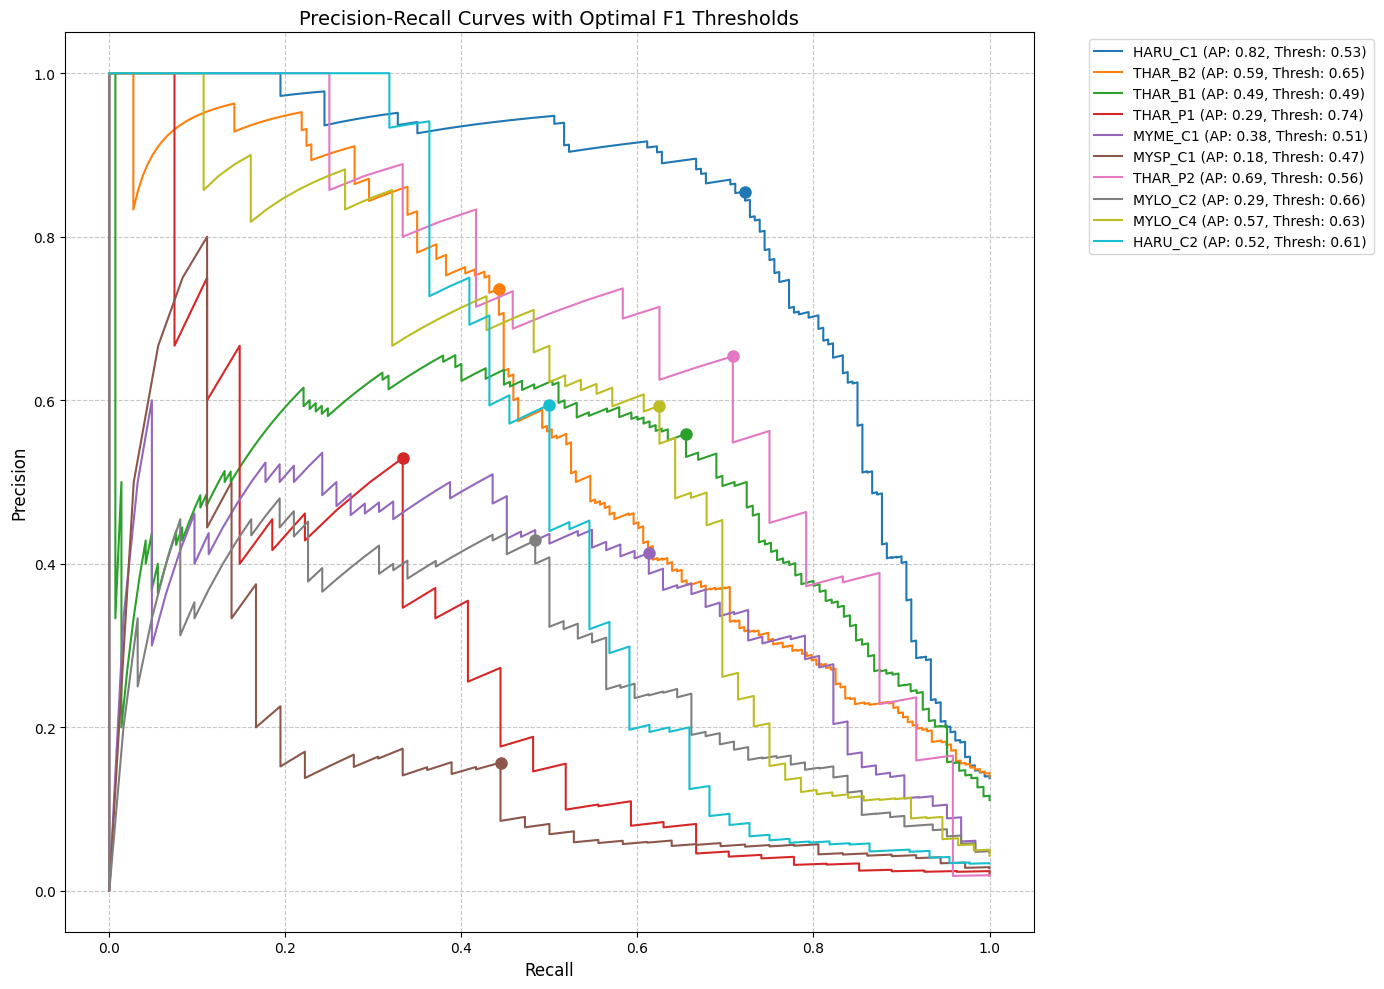


Optimal Thresholds (Maximized for F1):
  HARU_C1     : 0.526
  THAR_B2     : 0.645
  THAR_B1     : 0.489
  THAR_P1     : 0.737
  MYME_C1     : 0.507
  MYSP_C1     : 0.466
  THAR_P2     : 0.562
  MYLO_C2     : 0.662
  MYLO_C4     : 0.630
  HARU_C2     : 0.613


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

print("="*50)
print("THRESHOLD CALIBRATION")
print("="*50)

# initialize arrays to hold out of fold predictions and true labels
oof_Y_true = np.zeros_like(Y, dtype=float)
oof_Y_proba = np.zeros_like(Y, dtype=float)

# get predictions from folds
for train_emb, test_emb in custom_folds:
    # Split features and targets
    X_train, X_test = embeddings_multi_df.iloc[train_emb], embeddings_multi_df.iloc[test_emb]
    Y_train, Y_test = Y[train_emb], Y[test_emb]

    # Train
    multi_logreg.fit(X_train, Y_train)

    # Predict probabilities
    y_pred_proba_raw = multi_logreg.predict_proba(X_test)
    Y_pred_proba_positive = np.array([label_probs[:, 1] for label_probs in y_pred_proba_raw]).T

    # Store true labels and predicted probabilities for the test fold
    oof_Y_true[test_emb] = Y_test
    oof_Y_proba[test_emb] = Y_pred_proba_positive

# calculate PR Curves and find the optimal threshold for each class
best_thresholds = {}

plt.figure(figsize=(14, 10))

for i, label in enumerate(top_labels):
    y_true_class = oof_Y_true[:, i]
    y_proba_class = oof_Y_proba[:, i]

    # generate precision, recall, and threshold arrays
    precision, recall, thresholds = precision_recall_curve(y_true_class, y_proba_class)
    
    # get f1 scores
    f1_scores = np.divide(
        2 * precision * recall, 
        precision + recall, 
        out=np.zeros_like(precision), 
        where=(precision + recall) != 0
    )

    # find highest f1 score
    best_idx = np.argmax(f1_scores)
    best_f1 = f1_scores[best_idx]
    
    # thresholds array has length len(precision) - 1, so we handle the last index safely
    best_thresh = thresholds[best_idx] if best_idx < len(thresholds) else 1.0
    best_thresholds[label] = best_thresh

    # Plot the PR curve for this label
    ap_score = average_precision_score(y_true_class, y_proba_class)
    line, = plt.plot(recall, precision, label=f'{label} (AP: {ap_score:.2f}, Thresh: {best_thresh:.2f})')
    
    # Mark the optimal F1 threshold point on the curve
    plt.plot(recall[best_idx], precision[best_idx], marker='o', markersize=8, color=line.get_color())

    for t, p, r in zip(thresholds, precision, recall):
    # Only label every 100th threshold (or specific intervals) to avoid clutter
        if np.isclose(t, [0.2, 0.4, 0.6, 0.8], atol=0.01).any():
            plt.annotate(f'Th:{t:.2f}', (r, p), textcoords="offset points", 
                        xytext=(0,10), ha='center', fontsize=8, alpha=0.7)

# Formatting the plot
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves with Optimal F1 Thresholds', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Print out the dictionary of thresholds to use for future predictions
print("\nOptimal Thresholds (Maximized for F1):")
for label, thresh in best_thresholds.items():
    print(f"  {label:<12}: {thresh:.3f}")

In [27]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score
import warnings
warnings.filterwarnings("ignore")

print("="*50)
print("MULTICLASS LOGISTIC REGRESSION")
print("="*50)

label_names = labels_multi.columns
logreg_results = {label: {'f1': []} for label in label_names}
detailed_analysis = []

# for fold, (train_emb, test_emb) in enumerate(gkf_multi.split(embeddings_multi_df, labels_multi, groups=audio_files_multi)):
for fold, (train_emb, test_emb) in enumerate(custom_folds):
    
    #Split features
    X_train, X_test = embeddings_multi_df.iloc[train_emb], embeddings_multi_df.iloc[test_emb]
    
    # get targets
    Y_train = labels_multi.iloc[train_emb].astype(int).values
    Y_test = labels_multi.iloc[test_emb].astype(int).values

    # Train
    multi_logreg.fit(X_train, Y_train)

    #Predict
    y_pred_proba_raw = multi_logreg.predict_proba(X_test)

    Y_pred_proba_positive = np.array([label_probs[:, 1] for label_probs in y_pred_proba_raw]).T

    # default 0.5 threshold
    # Y_pred = (Y_pred_proba_positive >= 0.5).astype(int) # custom threshold, tune per-class later?
    
    # custom threshold numbers from the precision recall curve from previous cell
    threshold_array = np.array([best_thresholds[label] for label in top_labels])
    Y_pred = (Y_pred_proba_positive >= threshold_array).astype(int)

    # # Metrics
    # fold_f1 = f1_score(y_test_labels, y_pred, average='macro', zero_division=0)
    # logreg_results['f1'].append(fold_f1)

    # Process metadata for CSV
    test_indexes = embeddings_multi_df.iloc[test_emb].index
    
    for i, label in enumerate(label_names):
        y_t = Y_test[:, i]
        y_p = Y_pred[:, i]
        
        # Calculate F1 for this specific bird in this fold
        fold_f1 = f1_score(y_t, y_p, zero_division=0)
        logreg_results[label]['f1'].append(fold_f1)
        
        for idx in range(len(y_t)):
            actual = y_t[idx]
            pred = y_p[idx]
            
            category = None
            if actual == 1 and pred == 1:
                category = 'true_positive'
            elif actual == 0 and pred == 1:
                category = 'false_positive'
            elif actual == 1 and pred == 0:
                category = 'false_negative'

            if category is not None:
                
                detailed_analysis.append({
                    'fold': fold + 1,
                    'audio_file': test_indexes[idx][0],
                    'begin_time': test_indexes[idx][1],
                    'end_time': test_indexes[idx][1] + 2, 
                    'label': label,
                    'probability': Y_pred_proba_positive[idx, i],
                    'error_type': category
                })

    print(f"Fold {fold + 1} completed.")

# Summary Stats
print("\nAverage F1 per label across folds:")
for label in label_names:
    mean_f1 = np.mean(logreg_results[label]['f1'])
    std_f1 = np.std(logreg_results[label]['f1'])
    print(f"  {label:<15}: F1 = {mean_f1:.3f} ± {std_f1:.3f}")

# Final CSV Output
errors_df = pd.DataFrame(detailed_analysis)
csv_filename = 'model_errors_detailed_multilabel.csv'
errors_df.to_csv(csv_filename, index=False)
print(f"\nReport saved: {len(errors_df)} individual label mismatches found ({csv_filename}).")

MULTICLASS LOGISTIC REGRESSION
Fold 1 completed.
Fold 2 completed.
Fold 3 completed.
Fold 4 completed.
Fold 5 completed.

Average F1 per label across folds:
  HARU_C1        : F1 = 0.775 ± 0.034
  THAR_B2        : F1 = 0.550 ± 0.102
  THAR_B1        : F1 = 0.474 ± 0.280
  THAR_P1        : F1 = 0.425 ± 0.124
  MYME_C1        : F1 = 0.424 ± 0.316
  MYSP_C1        : F1 = 0.208 ± 0.163
  THAR_P2        : F1 = 0.638 ± 0.184
  MYLO_C2        : F1 = 0.390 ± 0.152
  MYLO_C4        : F1 = 0.594 ± 0.112
  HARU_C2        : F1 = 0.511 ± 0.142

Report saved: 1181 individual label mismatches found (model_errors_detailed_multilabel.csv).


In [28]:
import pandas as pd
from pathlib import Path

TARGET_LABEL = "MYSP_C1"  # change to look at other calls
INPUT_CSV = "model_errors_detailed_multilabel.csv"
OUTPUT_DIR = Path(f"raven_analysis_{TARGET_LABEL}")

OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Loading {INPUT_CSV}...")
df = pd.read_csv(INPUT_CSV)

# filter for bird
target_df = df[df['label'] == TARGET_LABEL].copy()

if len(target_df) == 0:
    print(f"No logged classifications found for {TARGET_LABEL}.")
else:
    print(f"Found {len(target_df)} total logged classifications for {TARGET_LABEL}.")
    
    print(target_df['error_type'].value_counts())
    print("-" * 50)

    # Group by audio file to create one Raven file per audio clip
    files_created = 0
    for audio_file, group in target_df.groupby('audio_file'):
        
        # initialize raven formatted df
        raven_df = pd.DataFrame()

        # Standard Raven required columns
        raven_df['Selection'] = range(1, len(group) + 1)
        raven_df['View'] = 'Spectrogram 1'
        raven_df['Channel'] = 1
        raven_df['Begin Time (s)'] = group['begin_time'].values
        raven_df['End Time (s)'] = group['end_time'].values
        raven_df['Low Freq (Hz)'] = 0      # Adjust if you want a specific box height
        raven_df['High Freq (Hz)'] = 22050 # Adjust if you want a specific box height
        
        # Custom metadata columns
        raven_df['Predicted Label'] = TARGET_LABEL
        raven_df['Classification Type'] = group['error_type'].values
        raven_df['Model Probability'] = group['probability'].values.round(4)
        raven_df['Fold'] = group['fold'].values

        # Format the output filename based on the audio file name
        # E.g., FFL-Annotations/Audio/TRIAL1_...wav -> MYSP_C1_TRIAL1_...txt
        audio_stem = Path(audio_file).stem
        output_filename = f"{TARGET_LABEL}_analysis_{audio_stem}.txt"
        output_filepath = OUTPUT_DIR / output_filename
        
        # Save as a tab-separated text file
        raven_df.to_csv(output_filepath, sep='\t', index=False)
        files_created += 1

    print(f"\nSuccess! Created {files_created} Raven selection tables in the '{OUTPUT_DIR.name}' folder.")

Loading model_errors_detailed_multilabel.csv...
Found 122 total logged classifications for MYSP_C1.
error_type
false_positive    86
false_negative    20
true_positive     16
Name: count, dtype: int64
--------------------------------------------------



Success! Created 26 Raven selection tables in the 'raven_analysis_MYSP_C1' folder.


In [29]:
print("Overall dataset counts:")
print("False Positives (Predicted bird, actual noise): ", (errors_df['error_type'] == 'false_positive').sum())
print("False Negatives (Predicted noise, actual bird): ", (errors_df['error_type'] == 'false_negative').sum())
print("Misclassifications (Confused two birds): ", (errors_df['error_type'] == 'misclassification').sum())
print("True Positives (Correctly identified bird): ", (errors_df['error_type'] == 'true_positive').sum())
print("True Negatives (Correctly identified noise): ", (errors_df['error_type'] == 'true_negative').sum())

csv_filename = 'model_errors_detailed_multi_logreg.csv'
errors_df.to_csv(csv_filename, index=False)
print(f"\nDetailed error report saved to: {csv_filename}")

Overall dataset counts:
False Positives (Predicted bird, actual noise):  362
False Negatives (Predicted noise, actual bird):  346
Misclassifications (Confused two birds):  0
True Positives (Correctly identified bird):  473
True Negatives (Correctly identified noise):  0

Detailed error report saved to: model_errors_detailed_multi_logreg.csv


In [30]:
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score
import numpy as np

print("=" * 50)
print("MULTI-LABEL PERCEPTRON")
print("=" * 50)

# Per-label results across folds
per_label_results = {label: {'auc': [], 'f1': [], 'precision': [], 'recall': []} for label in top_labels}

for fold, (train_idx, test_idx) in enumerate(gkf_multi.split(embeddings_multi_df, Y, groups=audio_files_multi)):

    X_train = embeddings_multi_df.iloc[train_idx]
    X_test  = embeddings_multi_df.iloc[test_idx]
    Y_train = Y[train_idx]
    Y_test  = Y[test_idx]

    # Train
    base_mlp.fit(X_train, Y_train)

    Y_pred_proba = base_mlp.predict_proba(X_test)

    Y_pred = base_mlp.predict(X_test)  # shape: (n_test, n_labels)

    fold_metrics = []
    for i, label in enumerate(top_labels):
        y_t = Y_test[:, i]
        y_p = Y_pred[:, i]
        y_s = Y_pred_proba[:, i]

        # Skip AUC if only one class present in this fold
        if len(np.unique(y_t)) < 2:
            auc = float('nan')
        else:
            auc = roc_auc_score(y_t, y_s)

        f1        = f1_score(y_t, y_p, zero_division=0)
        precision = precision_score(y_t, y_p, zero_division=0)
        recall    = recall_score(y_t, y_p, zero_division=0)

        per_label_results[label]['auc'].append(auc)
        per_label_results[label]['f1'].append(f1)
        per_label_results[label]['precision'].append(precision)
        per_label_results[label]['recall'].append(recall)

        fold_metrics.append(f"{label}: AUC={auc:.3f}, F1={f1:.3f}")

    print(f"\nFold {fold + 1}:")
    for m in fold_metrics:
        print(f"  {m}")

# Summary across folds
print("\n" + "=" * 50)
print("CROSS-VALIDATION AVERAGES (mean ± std)")
print("=" * 50)
for label in top_labels:
    r = per_label_results[label]
    auc_vals = [v for v in r['auc'] if not np.isnan(v)]
    print(
        f"{label:12s}  "
        f"AUC={np.mean(auc_vals):.3f}\u00b1{np.std(auc_vals):.3f}  "
        f"F1={np.mean(r['f1']):.3f}\u00b1{np.std(r['f1']):.3f}  "
        f"P={np.mean(r['precision']):.3f}  "
        f"R={np.mean(r['recall']):.3f}"
    )

MULTI-LABEL PERCEPTRON

Fold 1:
  HARU_C1: AUC=0.895, F1=0.733
  THAR_B2: AUC=0.700, F1=0.394
  THAR_B1: AUC=0.867, F1=0.333
  THAR_P1: AUC=0.834, F1=0.364
  MYME_C1: AUC=0.727, F1=0.333
  MYSP_C1: AUC=0.716, F1=0.235
  THAR_P2: AUC=0.934, F1=0.500
  MYLO_C2: AUC=0.720, F1=0.095
  MYLO_C4: AUC=0.777, F1=0.421
  HARU_C2: AUC=0.880, F1=0.667

Fold 2:
  HARU_C1: AUC=0.904, F1=0.732
  THAR_B2: AUC=0.880, F1=0.323
  THAR_B1: AUC=0.890, F1=0.598
  THAR_P1: AUC=0.588, F1=0.200
  MYME_C1: AUC=0.942, F1=0.471
  MYSP_C1: AUC=0.657, F1=0.222
  THAR_P2: AUC=0.604, F1=0.400
  MYLO_C2: AUC=0.900, F1=0.000
  MYLO_C4: AUC=0.906, F1=0.182
  HARU_C2: AUC=1.000, F1=0.800

Fold 3:
  HARU_C1: AUC=0.866, F1=0.653
  THAR_B2: AUC=0.892, F1=0.833
  THAR_B1: AUC=0.963, F1=0.579
  THAR_P1: AUC=0.958, F1=0.000
  MYME_C1: AUC=0.950, F1=0.000
  MYSP_C1: AUC=0.941, F1=0.000
  THAR_P2: AUC=0.987, F1=0.000
  MYLO_C2: AUC=0.763, F1=0.000
  MYLO_C4: AUC=0.980, F1=0.720
  HARU_C2: AUC=1.000, F1=0.000

Fold 4:
  HARU_C1: 

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score
import numpy as np
from sklearn.multioutput import MultiOutputClassifier

# Random forest to find the separability of THAR B1 and B2
base_rf = RandomForestClassifier(
    n_estimators=200, 
    max_depth=None, 
    n_jobs=-1, 
    random_state=42,
    class_weight='balanced' # Objective fix for class imbalance
)
randomForest = MultiOutputClassifier(base_rf)
print("=" * 50)
print("RANDOM FOREST")
print("=" * 50)

# Per-label results across folds
per_label_results = {label: {'auc': [], 'f1': [], 'precision': [], 'recall': []} for label in top_labels}

for fold, (train_idx, test_idx) in enumerate(gkf_multi.split(embeddings_multi_df, Y, groups=audio_files_multi)):

    X_train = embeddings_multi_df.iloc[train_idx]
    X_test  = embeddings_multi_df.iloc[test_idx]
    Y_train = Y[train_idx]
    Y_test  = Y[test_idx]

    # Train
    randomForest.fit(X_train, Y_train)

    # Y_pred_proba = randomForest.predict_proba(X_test)
    Y_pred_proba_raw = randomForest.predict_proba(X_test)
    Y_pred_proba_positive = np.array([label_probs[:, 1] for label_probs in Y_pred_proba_raw]).T
    CUSTOM_THRESHOLD = 0.20
    Y_pred = (Y_pred_proba_positive >= CUSTOM_THRESHOLD).astype(int)

    # Y_pred = randomForest.predict(X_test)  # shape: (n_test, n_labels)

    fold_metrics = []
    for i, label in enumerate(top_labels):
        y_t = Y_test[:, i]
        y_p = Y_pred[:, i]
        # y_s = Y_pred_proba[i][:, 1]
        y_s = Y_pred_proba_positive[:, i]

        # Skip AUC if only one class present in this fold
        if len(np.unique(y_t)) < 2:
            auc = float('nan')
        else:
            auc = roc_auc_score(y_t, y_s)

        f1        = f1_score(y_t, y_p, zero_division=0)
        precision = precision_score(y_t, y_p, zero_division=0)
        recall    = recall_score(y_t, y_p, zero_division=0)

        per_label_results[label]['auc'].append(auc)
        per_label_results[label]['f1'].append(f1)
        per_label_results[label]['precision'].append(precision)
        per_label_results[label]['recall'].append(recall)

        fold_metrics.append(f"{label}: AUC={auc:.3f}, F1={f1:.3f}")

    print(f"\nFold {fold + 1}:")
    for m in fold_metrics:
        print(f"  {m}")

# Summary across folds
print("\n" + "=" * 50)
print("CROSS-VALIDATION AVERAGES (mean ± std)")
print("=" * 50)
for label in top_labels:
    r = per_label_results[label]
    auc_vals = [v for v in r['auc'] if not np.isnan(v)]
    print(
        f"{label:12s}  "
        f"AUC={np.mean(auc_vals):.3f}\u00b1{np.std(auc_vals):.3f}  "
        f"F1={np.mean(r['f1']):.3f}\u00b1{np.std(r['f1']):.3f}  "
        f"P={np.mean(r['precision']):.3f}  "
        f"R={np.mean(r['recall']):.3f}"
    )


RANDOM FOREST

Fold 1:
  HARU_C1: AUC=0.929, F1=0.775
  THAR_B2: AUC=0.768, F1=0.434
  THAR_B1: AUC=0.649, F1=0.250
  THAR_P1: AUC=0.642, F1=0.000
  MYME_C1: AUC=0.836, F1=0.435
  MYSP_C1: AUC=0.730, F1=0.000
  THAR_P2: AUC=0.960, F1=0.500
  MYLO_C2: AUC=0.838, F1=0.286
  MYLO_C4: AUC=0.875, F1=0.450
  HARU_C2: AUC=0.849, F1=0.000

Fold 2:
  HARU_C1: AUC=0.928, F1=0.829
  THAR_B2: AUC=0.851, F1=0.191
  THAR_B1: AUC=0.883, F1=0.694
  THAR_P1: AUC=0.582, F1=0.000
  MYME_C1: AUC=0.966, F1=0.706
  MYSP_C1: AUC=0.770, F1=0.000
  THAR_P2: AUC=0.687, F1=0.400
  MYLO_C2: AUC=0.919, F1=0.222
  MYLO_C4: AUC=0.803, F1=0.286
  HARU_C2: AUC=0.997, F1=0.400

Fold 3:
  HARU_C1: AUC=0.876, F1=0.828
  THAR_B2: AUC=0.852, F1=0.577
  THAR_B1: AUC=0.984, F1=0.868
  THAR_P1: AUC=0.913, F1=0.000
  MYME_C1: AUC=0.931, F1=0.000
  MYSP_C1: AUC=0.922, F1=0.000
  THAR_P2: AUC=0.962, F1=0.462
  MYLO_C2: AUC=0.772, F1=0.000
  MYLO_C4: AUC=0.977, F1=0.733
  HARU_C2: AUC=1.000, F1=0.000

Fold 4:
  HARU_C1: AUC=0.823

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score
import numpy as np

# isolate THAR B1 B2 calls
b1_idx = list(top_labels).index('THAR_B1')
b2_idx = list(top_labels).index('HARU_C1')

# Look for lables with B1 xor B2
binary_mask = (Y[:, b1_idx] == 1) ^ (Y[:, b2_idx] == 1)

X_bin = embeddings_multi_df[binary_mask].reset_index(drop=True)
Y_bin = Y[binary_mask][:, b2_idx]  # Label 0 for B1, Label 1 for B2
groups_bin = np.array(audio_files_multi)[binary_mask]

print(f"Binary Separability for THAR B1 and B2")
print(f"Total pure samples: {len(X_bin)}")
print(f"B1 count: {np.sum(Y_bin == 0)} | B2 count: {np.sum(Y_bin == 1)}")

# Random forest to find the separability of THAR B1 and B2
binary_rf = RandomForestClassifier(
    n_estimators=200, 
    max_depth=None, 
    n_jobs=-1, 
    random_state=42,
    class_weight='balanced' # Objective fix for class imbalance
)

fold_results = []

for fold, (train_idx, test_idx) in enumerate(gkf_multi.split(X_bin, Y_bin, groups=groups_bin)):

    X_train_fold, X_test_fold = X_bin.iloc[train_idx], X_bin.iloc[test_idx]
    Y_train_fold, Y_test_fold = Y_bin[train_idx], Y_bin[test_idx]

    # Train
    binary_rf.fit(X_train_fold, Y_train_fold)

    # Predict
    y_pred = binary_rf.predict(X_test_fold)
    y_proba = binary_rf.predict_proba(X_test_fold)[:, 1]

    # Metrics
    acc = accuracy_score(Y_test_fold, y_pred)
    f1 = f1_score(Y_test_fold, y_pred)
    auc = roc_auc_score(Y_test_fold, y_proba) if len(np.unique(Y_test_fold)) > 1 else np.nan
    
    fold_results.append(acc)
    print(f"Fold {fold + 1}: Accuracy={acc:.3f}, F1={f1:.3f}, AUC={auc:.3f}")

mean_acc = np.mean(fold_results)
print(f"Mean Binary Accuracy: {mean_acc:.4f}")


Binary Separability for THAR B1 and B2
Total pure samples: 289
B1 count: 128 | B2 count: 161
Fold 1: Accuracy=0.914, F1=0.865, AUC=0.976
Fold 2: Accuracy=0.862, F1=0.871, AUC=0.987
Fold 3: Accuracy=0.948, F1=0.959, AUC=0.992
Fold 4: Accuracy=0.845, F1=0.886, AUC=0.960
Fold 5: Accuracy=0.982, F1=0.987, AUC=0.947
Mean Binary Accuracy: 0.9103
